In [29]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [9]:
df = pd.read_csv("~/Documents/Paris/Internship/Analyses/Pilot-Data/Big-Sets/Clean/spectral_data_Clean_ALL_IMPROV_pilots.csv", 
                  index_col = 0)

In [11]:
def ecdf(data):
    """Compute ECDF for a one-dimensional array of measurements."""
    # Number of data points: n
    n = len(data)
    # x-data for the ECDF: x
    x = np.sort(data)
    # y-data for the ECDF: y
    y = np.arange(1, n+1) / n
    return x, y

In [54]:
def draw_bs_reps(data, func, size=1):
    """Draw bootstrap replicates."""

    # Initialize array of replicates: bs_replicates
    bs_replicates = np.empty(size)

    # Generate replicates
    for i in range(size):
        bs_replicates[i] = bootstrap_replicate_1d(data, func)

    return bs_replicates

In [56]:
def bootstrap_replicate_1d(data, func):
    """Generate bootstrap replicate of 1D data."""
    bs_sample = np.random.choice(data, len(data))
    return func(bs_sample)

## Bootstrap samples

In [ ]:
# Resample the data again and recompute the summary statistic of interest.
# Resampling with replacement.
participants = list(df['PARTICIPANT_ID'].unique())
bs_samples = []

for p in participants:
    for _ in range(100):
        # Generate bootstrap sample: bs_sample
        bs_sample = np.random.choice(df[df['PARTICIPANT_ID']==p]['FUNDAMENTAL_FREQUENCY'], size=1290)
        bs_samples.append(bs_sample)

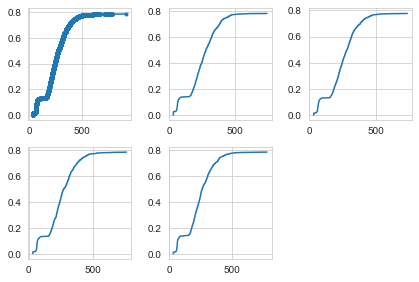

In [43]:
# sns.set_style('whitegrid')

# # Compute and plot ECDF from bootstrap sample
# x_all = []
# y_all = []
# for i in range(len(participants)):
#     x, y = ecdf(bs_samples[i])
#     x_all.append(x)
#     y_all.append(y)

# xs = []
# ys = []
# for p in participants: 
#     xe, ye = ecdf(df[df['PARTICIPANT_ID']==p]['FUNDAMENTAL_FREQUENCY'])
#     xs.append(xe)
#     ys.append(ye)
    
# # Define plotting region
# fig, ((ax1, ax2, ax3), (ax4, ax5, ax6))  = plt.subplots(nrows=2, ncols=3, tight_layout=True)

# ax1.plot(x_all[0], y_all[0], marker='.', linestyle='none', color='gray', alpha=0.1)
# ax1.plot(xs[0], ys[0], marker='.')
# ax2.plot(x_all[1], y_all[1])
# ax3.plot(x_all[2], y_all[2])
# ax4.plot(x_all[3], y_all[3])
# ax5.plot(x_all[4], y_all[4])

# ax6.set_visible(False)

# # Label axes

## Bootstrap replicates

In [61]:
# Obtain the statistics from the bootstrap samples.
# Nonparametric inference.
bs_replicates = draw_bs_reps(data=df[df['PARTICIPANT_ID']==999]['FUNDAMENTAL_FREQUENCY'], func=np.max, size=10000)

ValueError: autodetected range of [nan, nan] is not finite

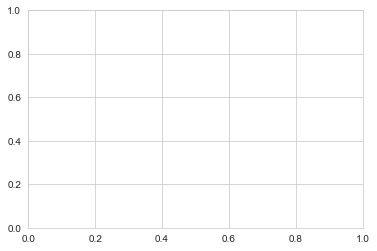

In [62]:
# Plot a histogram of bootstrap replicates.
_= plt.hist(bs_replicates, bins=30, normed=True)
_= plt.xlabel('f0')
_= plt.ylabel('PDF')

In [ ]:
# # Compute and print SEM
# sem = np.std(rainfall) / np.sqrt(len(rainfall))
# print(sem)

# # Compute and print standard deviation of bootstrap replicates
# bs_std = np.std(bs_replicates)
# print(bs_std)

In [51]:
# Get confidence intervals.
np.percentile(bs_replicates, q=[2.5, 97.5]) # 95% CI

NameError: name 'bs_replicates' is not defined

## Test Hypothesis

In [ ]:
# Use the resampled data to perform statistical inference: check whether the effect is due to random chance.

In [2]:
# State null hypothesis: the true mean number of tones is equal to Angalada-Tort experiment. So, if we did pilot experiment lots
# and lots of times, we would have gotten the same result as them. Comparing a dataset to a value == one samples test.

# Song universals: small pitch sets (smaller than 7 per octave), 
                #  small pitch intervals (smaller than 7 semitones), 
                #  arc-shaped melodies

In [ ]:
# Define test statistic.

In [ ]:
# Shift the data & perform bootstrapping on the shifted data.

In [ ]:
# Estimate p-value: if Angalada-Tort mean no. pitches is lower than ours <= if higher >= !!